<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/_train_simclr_har_1s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SimCLR Training

In [ ]:
# For VSCode
%load_ext autoreload
%autoreload 2

import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt

sys.path.append('../')   # Add parent directory to Python path
working_directory = "../models/"

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

with open('../data_1s/TrainTest/X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('../data_1s/TrainTest/y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('../data_1s/TrainTest/X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('../data_1s/TrainTest/y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('../data_1s/TrainTest/X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('../data_1s/TrainTest/y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

np_train_data.shape, np_train_labels.shape, np_val_data.shape, np_val_labels.shape, np_test_labels.shape

((2603, 100, 3), (2603, 7), (651, 100, 3), (651, 7), (814, 7))

In [1]:
# For Google Colab
# 1. Clone your repository to go to access your notebook and .py files
!git clone https://github.com/Ziyi-star/Bachelorarbeit.git
# 2. Change working directory to where your notebook and .py files are
import os
os.chdir('/content/Bachelorarbeit/notebooks/training')
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import simclr_utitlities
import transformations
import simclr_models
import sys

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load data
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s/TrainTest/X_train_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s/TrainTest/y_train_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s/TrainTest/X_val_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s/TrainTest/y_val_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s/TrainTest/X_test_data.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s/TrainTest/y_test_onehot.pkl


working_directory = "../models/"  # Relative path to models folder

# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_data = pickle.load(f)
with open('y_train_onehot.pkl', 'rb') as f:
    np_train_labels = pickle.load(f)
with open('X_val_normalized.pkl', 'rb') as f:
    np_val_data = pickle.load(f)
with open('y_val_onehot.pkl', 'rb') as f:
    np_val_labels = pickle.load(f)
with open('X_test_data.pkl', 'rb') as f:
    np_test_data = pickle.load(f)
with open('y_test_onehot.pkl', 'rb') as f:
    np_test_labels = pickle.load(f)

print(np_train_data.shape, np_train_labels.shape)
print(np_val_data.shape, np_val_labels.shape)

Cloning into 'Bachelorarbeit'...
remote: Enumerating objects: 572, done.
remote: Counting objects: 100% (173/173), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 572 (delta 114), reused 108 (delta 59), pack-reused 399 (from 2)
Receiving objects: 100% (572/572), 156.84 MiB | 15.98 MiB/s, done.
Resolving deltas: 100% (339/339), done.
Updating files: 100% (64/64), done.


/content/Bachelorarbeit/notebooks/training/transformations.py:35: SyntaxWarning: invalid escape sequence '\&'
  @inproceedings{TerryUm_ICMI2017, author = {Um, Terry T. and Pfister, Franz M. J. and Pichler, Daniel and Endo, Satoshi and Lang, Muriel and Hirche, Sandra and Fietzek, Urban and Kuli\'{c}, Dana}, title = {Data Augmentation of Wearable Sensor Data for Parkinson's Disease Monitoring Using Convolutional Neural Networks}, booktitle = {Proceedings of the 19th ACM International Conference on Multimodal Interaction}, series = {ICMI 2017}, year = {2017}, isbn = {978-1-4503-5543-8}, location = {Glasgow, UK}, pages = {216--220}, numpages = {5}, doi = {10.1145/3136755.3136817}, acmid = {3136817}, publisher = {ACM}, address = {New York, NY, USA}, keywords = {Parkinson\&#39;s disease, convolutional neural networks, data augmentation, health monitoring, motor state detection, wearable sensor}, }


--2025-09-25 12:37:31--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s/TrainTest/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6247365 (6.0M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]   5.96M  --.-KB/s    in 0.02s   

2025-09-25 12:37:32 (377 MB/s) - ‘X_train_normalized.pkl’ saved [6247365/6247365]

--2025-09-25 12:37:32--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/data_1s/TrainTest/y_train_onehot.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111

## 1.1 Pretraining with SimCLR

In [2]:
# Parameters for all experiments
window_size = 100
input_shape = (window_size, 3)
batch_size = 512
#Number of samples processed together in one training step. Larger batch sizes can speed up training but require more memory.
decay_steps = 1000
#Number of steps after which the learning rate decays (used for learning rate scheduling).
epochs = 200
temperature = 0.1


In [3]:
#A parameter for the SimCLR loss function that controls how sharply similarities are measured.
# transform_funcs = [
#     transformations.scaling_transform_vectorized, # Use Scaling trasnformation
#     transformations.rotation_transform_vectorized # Use rotation trasnformation
# ]
transform_funcs = [
    transformations.time_segment_permutation_transform_improved,
    transformations.channel_shuffle_transform_vectorized
]
#List of data augmentation functions to apply to the input data. Here, only rotation is used.
transformation_function = simclr_utitlities.generate_composite_transform_function_simple(transform_funcs)

0 <function time_segment_permutation_transform_improved at 0x7fb776e41080>
1 <function channel_shuffle_transform_vectorized at 0x7fb776e40fe0>


In [4]:
# Time
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
#Formats the date and time as a string like 20250827-153045 (for filenames, logs, etc.).
tf.keras.backend.set_floatx('float32')
#Sets TensorFlow to use 32-bit floating point numbers for all computations (standard for deep learning).


In [5]:
# Create a cosine-decayed learning rate schedule and SGD optimizer for training.
lr_decayed_fn = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.1, decay_steps=decay_steps)
optimizer = tf.keras.optimizers.SGD(lr_decayed_fn)

# Build the base model and attach the SimCLR head for contrastive learning.
base_model = simclr_models.create_base_model(input_shape, model_name="base_model")
simclr_model = simclr_models.attach_simclr_head(base_model)
simclr_model.summary()

# Train the SimCLR model using the specified transformation function and optimizer.
trained_simclr_model, epoch_losses = simclr_utitlities.simclr_train_model(
    simclr_model,
    np_train_data,
    optimizer,
    batch_size,
    transformation_function,
    temperature=temperature,
    epochs=epochs,
    is_trasnform_function_vectorized=True,
    verbose=1
)

# Save the trained SimCLR model to disk for later use.
simclr_model_save_path = f"{working_directory}{start_time_str}_simclr.hdf5"
trained_simclr_model.save(simclr_model_save_path)

Model: "base_model_simclr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 77, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 77, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 62, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 55, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 55, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,594 (580.45 KB)

 Trainable params: 148,594 (580.45 KB)

 Non-trainable params: 0 (0.00 B)

epoch: 1 loss: 11.594
epoch: 2 loss: 11.622
epoch: 3 loss: 10.714
epoch: 4 loss: 9.962
epoch: 5 loss: 10.887
epoch: 6 loss: 10.011
epoch: 7 loss: 9.219
epoch: 8 loss: 8.656
epoch: 9 loss: 8.579
epoch: 10 loss: 8.907
epoch: 11 loss: 8.357
epoch: 12 loss: 8.700
epoch: 13 loss: 8.115
epoch: 14 loss: 7.624
epoch: 15 loss: 7.494
epoch: 16 loss: 7.906
epoch: 17 loss: 7.366
epoch: 18 loss: 7.170
epoch: 19 loss: 6.788
epoch: 20 loss: 6.880
epoch: 21 loss: 6.550
epoch: 22 loss: 7.071
epoch: 23 loss: 6.522
epoch: 24 loss: 6.366
epoch: 25 loss: 6.529
epoch: 26 loss: 6.265
epoch: 27 loss: 6.075
epoch: 28 loss: 6.355
epoch: 29 loss: 6.152
epoch: 30 loss: 5.977
epoch: 31 loss: 6.171
epoch: 32 loss: 5.770
epoch: 33 loss: 5.778
epoch: 34 loss: 5.497
epoch: 35 loss: 5.547
epoch: 36 loss: 5.431
epoch: 37 loss: 5.658
epoch: 38 loss: 5.522
epoch: 39 loss: 5.329
epoch: 40 loss: 5.465
epoch: 41 loss: 5.263
epoch: 42 loss: 5.294
epoch: 43 loss: 5.223
epoch: 44 loss: 5.037
epoch: 45 loss: 5.100
epoch: 46 loss

epoch: 200 loss: 2.367


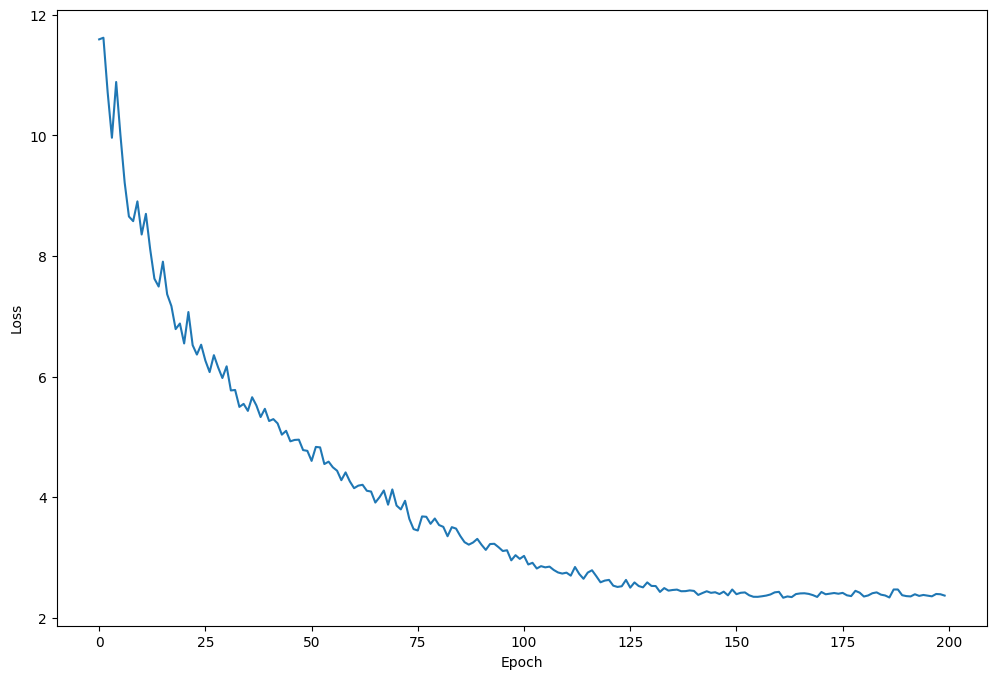

In [6]:
# Plot history of training losses over epochs.
plt.figure(figsize=(12,8))
plt.plot(epoch_losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

## 1.2 Fine-tuning and Evaluation

### 1.2.1 Linear Model

#### Train

In [7]:
# This block performs linear evaluation on top of the pretrained SimCLR base model.
total_epochs = 50
batch_size = 200
tag = "linear_eval"
output_shape = np_train_labels.shape[1]  # Number of classes for classification

# 1. Loads the SimCLR model and attaches a linear classification head on top.
simclr_model = tf.keras.models.load_model(simclr_model_save_path)
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

# 2. Sets up a ModelCheckpoint callback to save the best model (lowest validation loss).
# This ensures we keep the model version that performs best on validation data
linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(
    linear_eval_best_model_file_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

# 3. Trains the linear evaluation model using the training and validation data.
training_history = linear_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 357ms/step - auc: 0.6773 - categorical_accuracy: 0.3222 - loss: 1.8201 - precision: 0.5586 - recall: 0.0895 - val_auc: 0.6671 - val_categorical_accuracy: 0.2873 - val_loss: 1.9346 - val_precision: 0.4498 - val_recall: 0.1444
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.7807 - categorical_accuracy: 0.4370 - loss: 1.5823 - precision: 0.7364 - recall: 0.1767 - val_auc: 0.7252 - val_categorical_accuracy: 0.3257 - val_loss: 1.7546 - val_precision: 0.5707 - val_recall: 0.1797
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.8120 - categorical_accuracy: 0.4760 - loss: 1.4729 - precision: 0.7802 - recall: 0.2124 - val_auc: 0.7869 - val_categorical_accuracy: 0.3902 - val_loss: 1.5453 - val_precision: 0.6798 - val_recall: 0.2120
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - auc: 0.8377 - categorical_accuracy: 0.5093 - loss: 1.3718 - precision: 0.8080 - recall: 0.2351 - val_auc: 0.8010 - val_categorical_accuracy: 0.3948 - 

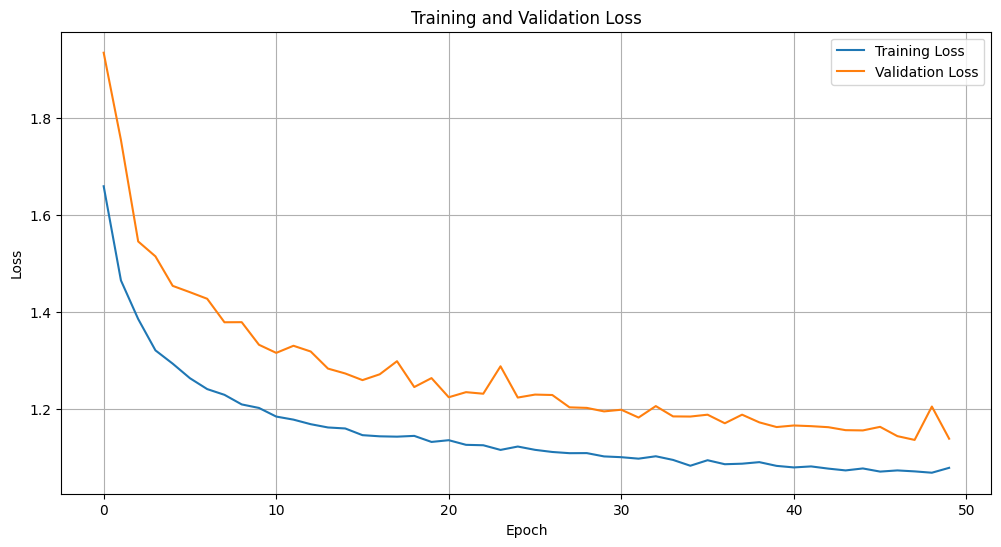

In [8]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

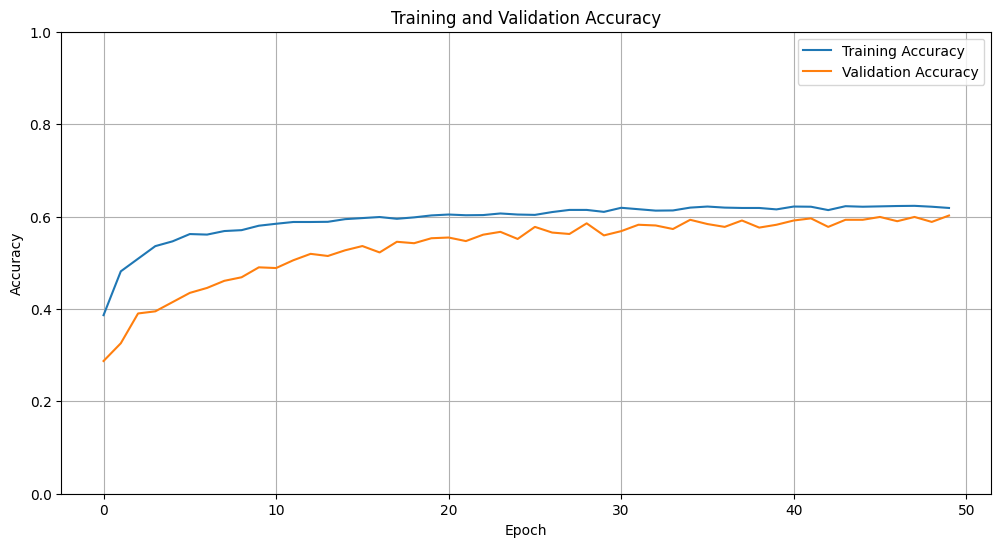

In [9]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [12]:
# Load models and evaluate on test set on vscode
linear_eval_model_path =  tf.keras.models.load_model(linear_eval_best_model_file_name)

# Load both models
# simclr_model = tf.keras.models.load_model(simclr_model_path)
linear_eval_best_model = tf.keras.models.load_model(linear_eval_model_path)

#### Normalize test data

In [13]:
from sklearn.preprocessing import StandardScaler

def normalize_3d_data(data):
    """
    Normalize 3D sensor data (samples, timesteps, features) using StandardScaler.

    Parameters:
    -----------
    data : list or numpy.ndarray
        Input data. If a list of arrays, it will be stacked first.
        Shape should be (N, L, C) where:
        N = number of samples, L = segment length (timesteps), C = number of channels/features

    Returns:
    --------
    numpy.ndarray
        Normalized data with the same shape as input
    """
    # Stack data if it's a list
    if isinstance(data, list):
        data_array = np.stack(data)  # shape: (N, L, C)
    else:
        data_array = data

    # Get dimensions
    N, L, C = data_array.shape

    # Reshape to 2D for scaling: (N*L, C)
    data_reshaped = data_array.reshape(-1, C)

    # Apply standard scaling
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data_reshaped)

    # Reshape back to original 3D shape
    data_normalized = data_scaled.reshape(N, L, C)

    return data_normalized

In [14]:
# You can also use it for test data (but should fit the scaler only on training data)
X_test_normalized = normalize_3d_data(np_test_data)

In [15]:
linear_eval_best_model = tf.keras.models.load_model(linear_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(linear_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(linear_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
{'Confusion Matrix': array([[119,   2,  10,   2,   0,   1,   5],
       [  7,  72,   3,   2,   3,   4,   6],
       [ 38,   7,  28,   0,   3,  15,   4],
       [ 11,  13,   2,  80,   3,   4,   7],
       [  0,   7,   3,   2, 108,   0,   0],
       [ 23,   5,   3,   0,   0,  68,  16],
       [ 58,   5,   4,   3,   2,  35,  21]]), 'F1 Macro': 0.5898737210603391, 'F1 Micro': 0.6093366093366094, 'F1 Weighted': 0.5903517993396186, 'Precision': 0.6199427127716486, 'Recall': 0.6021647865355427, 'Kappa': np.float64(0.5411182198680005)}
Model in last epoch
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
{'Confusion Matrix': array([[119,   2,  10,   2,   0,   1,   5],
       [  8,  73,   3,   2,   4,   4,   3],
       [ 40,   7,  28,   0,   3,  15,   2],
       [ 11,  13,   1,  81,   3,   4,   7],
       [  0,   6,   3,   2, 109,   0,   0],
       [ 23,   6,   3,   0,   0,  68,  15],
       [ 61,   5,   4,   3,   2,  36,  17]]), 

### 1.2.2 Full HAR Model

#### Train

In [16]:
total_epochs = 50
batch_size = 200
tag = "full_eval"

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
full_evaluation_model = simclr_models.create_full_classification_model_from_base_model(
    simclr_model, output_shape, model_name="TPN", intermediate_layer=7, last_freeze_layer=4)

full_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"

best_model_callback = tf.keras.callbacks.ModelCheckpoint(full_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = full_evaluation_model.fit(
    x = np_train_data,
    y = np_train_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_data, np_val_labels)
)



Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 723ms/step - auc: 0.6867 - categorical_accuracy: 0.3127 - loss: 1.8392 - precision: 0.5964 - recall: 0.1402 - val_auc: 0.8511 - val_categorical_accuracy: 0.5315 - val_loss: 1.3267 - val_precision: 0.7360 - val_recall: 0.2826
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.8731 - categorical_accuracy: 0.5588 - loss: 1.2277 - precision: 0.7289 - recall: 0.3684 - val_auc: 0.8884 - val_categorical_accuracy: 0.5868 - val_loss: 1.1746 - val_precision: 0.8514 - val_recall: 0.3257
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.8970 - categorical_accuracy: 0.6113 - loss: 1.1126 - precision: 0.7744 - recall: 0.4188 - val_auc: 0.9035 - val_categorical_accuracy: 0.6298 - val_loss: 1.0934 - val_precision: 0.8401 - val_recall: 0.3794
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - auc: 0.9101 - categorical_accuracy: 0.6273 - loss: 1.0454 - precision: 0.7894 - recall: 0.4496 - val_auc: 0.9099 - val_categorical_accuracy: 0.6359 - 

#### Plot metrics

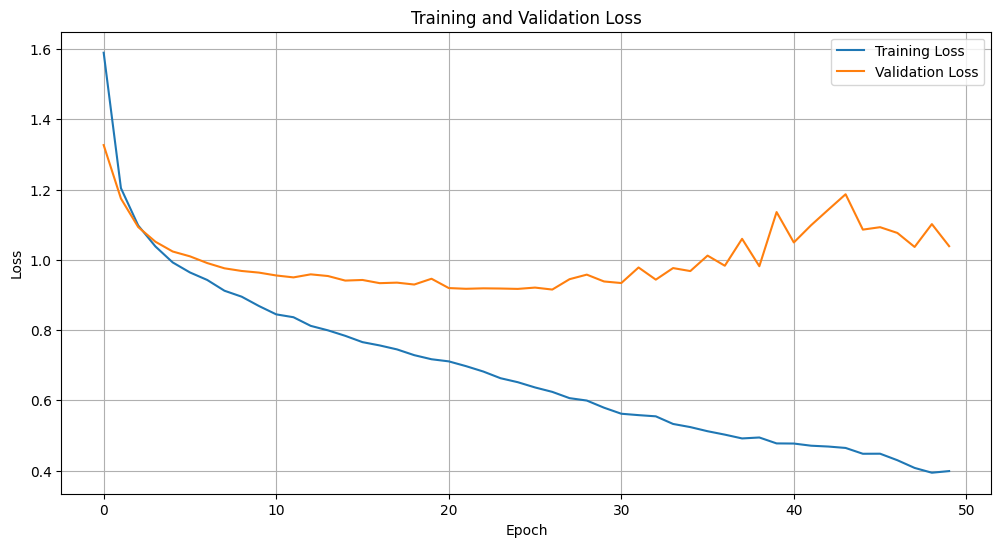

In [17]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

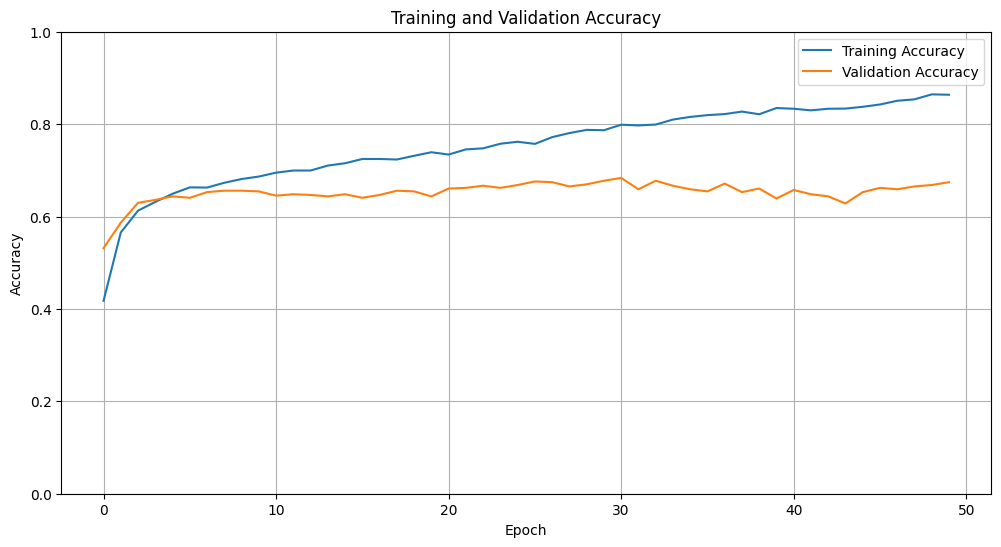

In [18]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [22]:
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(full_eval_best_model.predict(X_test_normalized), np_test_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(full_evaluation_model.predict(X_test_normalized), np_test_labels, return_dict=True))


Model with lowest validation Loss:
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
{'Confusion Matrix': array([[112,   1,  12,   0,   1,   1,  12],
       [  7,  72,   2,   3,   3,   7,   3],
       [ 27,   2,  36,   3,   1,   7,  19],
       [  2,   2,   1, 108,   5,   2,   0],
       [  0,   1,   1,   3, 115,   0,   0],
       [ 16,   2,  12,   2,   0,  65,  18],
       [ 42,   2,   7,   5,   3,  17,  52]]), 'F1 Macro': 0.6794139042688474, 'F1 Micro': 0.687960687960688, 'F1 Weighted': 0.6808925901705234, 'Precision': 0.6935358932712031, 'Recall': 0.679538789997043, 'Kappa': np.float64(0.6336231185520427)}
Model in last epoch
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
{'Confusion Matrix': array([[116,   0,   8,   1,   0,   1,  13],
       [  8,  68,   3,   3,   2,   8,   5],
       [ 26,   0,  34,   3,   0,   9,  23],
       [  4,   0,   0, 109,   5,   1,   1],
       [  0,   1,   1,   4, 114,   0,   0],
       [ 19,   0,   9,   0,   0,  60,  27],
       [ 47,   1,   5,   1,   1,  14,  59]]), 'F

## Extra: t-SNE Plots

### Parameters

In [20]:
import sklearn.manifold
import seaborn as sns

### t-SNE Representations

In [23]:
# First load the model from the file path
target_model_path = simclr_model_save_path
loaded_model = tf.keras.models.load_model(target_model_path)
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(loaded_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(X_test_normalized, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "base_model_simclr_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 100, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 77, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 77, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 62, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 62, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 55, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 55, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 84,416 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 464ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 814 samples in 0.001s...
[t-SNE] Computed neighbors for 814 samples in 0.073s...
[t-SNE] Computed conditional probabilities for sample 814 / 814
[t-SNE] Mean sigma: 1.498243
[t-SNE] KL divergence after 250 iterations with early exaggeration: 60.632198
[t-SNE] KL divergence after 1000 iterations: 0.685266


### Plotting

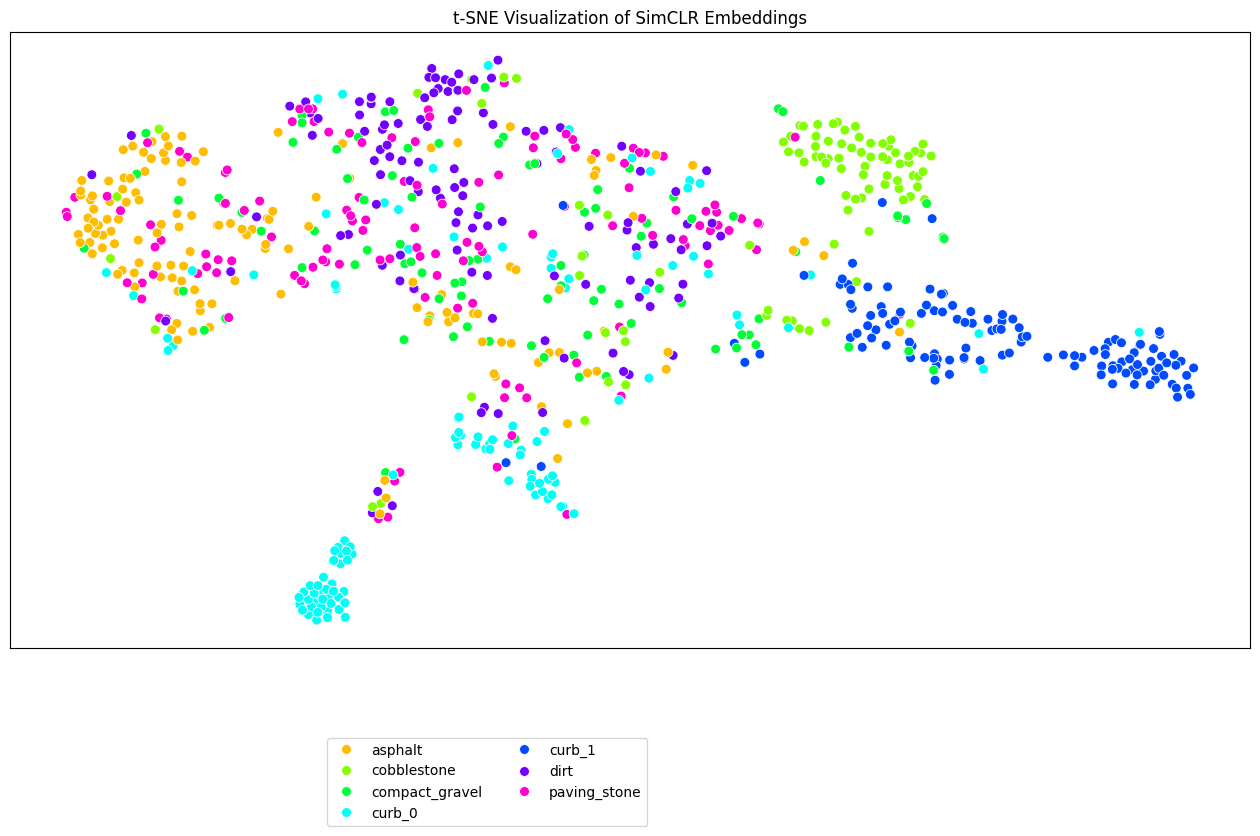

In [24]:
# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_labels, axis=1)
unique_labels = np.unique(labels_argmax)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=sns.color_palette("hsv", len(unique_labels)),
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# If you have class names, use them for the legend
# Define your activity names if needed
label_list_full_name = ["asphalt", "cobblestone", "compact_gravel", "curb_0", "curb_1", "dirt", "paving_stone"]  # Replace with your actual class names

# Update legend with class names if available
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():  # Check if variable exists
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)